### 1. Introducción 

El modelo principal de referencia en el sector bancario para Application Scoring  (scoring de admisión) es la **Regresión Logística con transformación WoE** (Weight of Evidence, peso de la evidencia). Su adopción está respaldada por las guías de la  EBA (European Banking Authority, Autoridad Bancaria Europea) sobre modelos IRB  (Internal Ratings-Based, basados en calificaciones internas), y su interpretabilidad  directa facilita la validación regulatoria.

El objetivo de esta fase es construir un **benchmark**:  entrenar modelos alternativos y evaluar si ofrecen una capacidad discriminante  superior al modelo campeón.

#### 1.1 Métodos elegidos para realizar el benchmark

He seleccionado modelos de Gradient Boosting (potenciación del gradiente) por las  siguientes razones:

1. **Rendimiento empírico superior** en datos tabulares financieros, documentado en  la literatura de referencia sobre scoring crediticio (Lessmann et al., 2015).
2. **Robustez ante outliers (valores atípicos) y variables asimétricas**,  características predominantes en el dataset HMEQ identificadas durante el EDA.
3. **Gestión nativa de missing values (valores ausentes)** en LightGBM, evitando decisiones de imputación que podrían introducir sesgo.

Se entrenan dos implementaciones para validar la estabilidad de los resultados:
- **LightGBM**: optimizado en memoria y velocidad, gestiona los valores ausentes de forma nativa.
- **XGBoost**: implementación clásica ampliamente auditada en entornos bancarios, requiere imputación previa de valores ausentes.

En relación con la evaluación, se emplean las mismas métricas que en la Regresión Logística, permitiendo una comparación homogénea: AUC-ROC , KS , Gini y Brier Score.

#### 1.2 Métodos descartados

- **Random Forest** (familia bagging): menor poder predictivo empírico que boosting en datos tabulares financieros (Lessmann et al., 2015). Al ser también un conjunto de árboles, no aporta información adicional sobre el techo de discriminación que ya estima el estado del arte (boosting).
- **Redes neuronales**: actúan como "caja negra" sin un beneficio claro sobre boosting en datasets de tamaño moderado, lo que dificulta su defensa ante el regulador.
- **SVM** (Support Vector Machine, máquina de vectores de soporte): de la familia de métodos kernel, no produce probabilidades calibradas de forma directa; está diseñado para clasificación binaria dura, no para scoring continuo.
- **KNN** (K-Nearest Neighbors, K vecinos más cercanos): muy sensible a la escala y a la dimensionalidad, y sin capacidad de extrapolación.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

### 2. Carga de datos

In [2]:
# Cargar el dataset y hacer una copia
hmeq = pd.read_csv('../data/raw/hmeq.csv')
hmeq_prep_2 = hmeq.copy()

### 3. Pipeline de preprocesamiento y modelización

#### 3.1 Separación train/test

In [3]:
# train y test split
X = hmeq_prep_2.drop(columns="BAD")
y = hmeq_prep_2["BAD"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123, stratify=y)    

In [4]:
print(f"Total : {len(X)}")
print(f"Train : {len(X_train)}")
print(f"Test: {len(X_test)}")
print(f"Proporción de defaults):")
print(f"Total : {y.mean():.3f}")
print(f"Train : {y_train.mean():.3f}")
print(f"Test  : {y_test.mean():.3f}")

Total : 5960
Train : 4172
Test: 1788
Proporción de defaults):
Total : 0.199
Train : 0.199
Test  : 0.200


#### 3.2 Pipeline de preprocesamiento — ColumnTransformer

El preprocesamiento se implementa mediante un ColumnTransformer
Se definen tres grupos de variables:

**Variables numéricas para LightGBM:**
Creación de CLTV, cap en 2.55 y eliminación de MORTDUE y VALUE.
LightGBM gestiona missing values de forma nativa — no se imputan.

**Variables numéricas para XGBoost:**
Idéntico tratamiento más imputación por mediana.
XGBoost no gestiona missing values nativamente.

**Variables categóricas (ambos modelos):**
REASON y JOB — missing como categoría explícita + OrdinalEncoder.
Se usa OrdinalEncoder en lugar de LabelEncoder porque es compatible
con el pipeline de scikit-learn.

In [5]:
from sklearn.pipeline import Pipeline   
from sklearn.compose import ColumnTransformer  
from sklearn.preprocessing import OrdinalEncoder     
from sklearn.impute import SimpleImputer    
from sklearn.base import BaseEstimator, TransformerMixin, clone 

### 3.2.bis — Clase propia CLTVTransformer

La clase `CLTVTransformer`, responsable de construir la variable Combined Loan-to-Value dentro del pipeline, se ha extraído al módulo compartido `src/transformers.py` para:

- Evitar duplicación de código entre los notebooks 03 (LightGBM), 04 (XGBoost) y 05 (comparación).
- Permitir que los Pipelines serializados con `joblib.dump` apunten a una referencia estable (`src.transformers.CLTVTransformer`) en vez de `__main__`, lo que permite cargarlos desde cualquier notebook posterior sin reproducir la definición.

Esta separación sigue el patrón estándar en entornos bancarios de producción, donde los transformers personalizados se empaquetan en librerías internas auditables.

In [6]:
#  Importar clase propia desde módulo compartido src/ 
import sys                                               # Módulo estándar para manipular el path de Python
from pathlib import Path                                 # Manejo de rutas multiplataforma
sys.path.append(str(Path.cwd().parent))                  # Añadir la raíz del proyecto al path de Python
from src.transformers import CLTVTransformer             # Importar desde el módulo compartido

In [7]:
# Variables categóricas — requieren encoding
vars_categoricas = ["REASON", "JOB"]

# Variables numéricas originales — MORTDUE y VALUE se eliminan dentro del
# CLTVTransformer, por lo que no se incluyen aquí como destino final
vars_numericas = ["LOAN", "YOJ", "DEROG", "DELINQ", "CLAGE", "NINQ", "CLNO", "DEBTINC", "MORTDUE", "VALUE"]

print("Variables categóricas :", vars_categoricas)
print("Variables numéricas   :", vars_numericas)

Variables categóricas : ['REASON', 'JOB']
Variables numéricas   : ['LOAN', 'YOJ', 'DEROG', 'DELINQ', 'CLAGE', 'NINQ', 'CLNO', 'DEBTINC', 'MORTDUE', 'VALUE']


#### 3.3 Construcción de los pipelines

Se construyen dos pipelines independientes, uno por modelo. Ambos comparten la lógica de preprocesamiento pero difieren en el tratamiento de missing values en variables numéricas:

- **Pipeline LightGBM**: no imputa missing values numéricos. LightGBM aprende internamente la dirección óptima para los NaN  minimizando la función de pérdida en cada split, lo que constituye una ventaja metodológica.

- **Pipeline XGBoost**: imputa missing values numéricos con la mediana calculada exclusivamente sobre el conjunto de train, evitando data leakage desde el conjunto de test.

En ambos casos las variables categóricas reciben el mismo tratamiento: missing imputado como categoría explícita "Missing" seguido de OrdinalEncoder, que asigna un entero a cada categoría.

In [8]:
# Construcción del pipeline de preprocesamiento
import lightgbm as lgb    # Modelo LightGBM
import xgboost as xgb     # Modelo XGBoost

# Preprocesamiento variables categoricas. Aplica a ambos modelos, LightGBM y XGBoost.
prep_categoricas = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")), # Imputación de missing values con la categoría "missing"
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)) # Codificación ordinal, asignando -1 a categorías desconocidas. Esto nos da una señal inequívoca de categoría desconocida en vez de "romper" el pipeline. 
])

# Preprocesamiento variables numéricas. 
# 1. LightGBM: Solo aplicamos el CLTVTransformer, ya que ambos maneja internamente los missing values. 

prep_numericas_lightgbm = Pipeline(steps=[
    ("cltv", CLTVTransformer(cap=2.55)) # Calcula CLTV, aplica CAP y elimina MORTDUE y VALUE 
])

prep_numericas_xgb = Pipeline(steps=[
    ("cltv", CLTVTransformer(cap=2.55)),
])

In [9]:
# Definimos el columntransformer para cada modelo. 
# 1. LightGBM
preprocessor_lightgbm = ColumnTransformer(transformers=[
    ("num", prep_numericas_lightgbm, vars_numericas),
    ("cat", prep_categoricas, vars_categoricas)
], remainder="drop") # Solo mantiene las columnas transformadas. 

preprocessor_lightgbm

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,cap,2.55
,missing_values,nan
,strategy,'constant'


In [10]:
# 2. XGBoost
preprocessor_xgb = ColumnTransformer(transformers=[
    ("num", prep_numericas_xgb, vars_numericas),
    ("cat", clone(prep_categoricas), vars_categoricas) # usamos clone para evitar que el mismo objeto prep_categoricas se comparta entre ambos pipelines, lo que podría causar problemas si se ajusta en uno de ellos.
], remainder="drop")

preprocessor_xgb

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,cap,2.55
,missing_values,nan
,strategy,'constant'


In [11]:
# Pipelines finales (preprocesamiento más modelo)
# Los hiperparámetros (n_estimators, max_depth, learning_rate, etc) se fijarán mas adelante con GridsearchCV. Tan solo se fijan parámetros fijos. 
# 1. LightGBM
pl_lgbm = Pipeline(steps=[
    ("prep_light", preprocessor_lightgbm),
    ("model_light", lgb.LGBMClassifier(
        objective="binary",
        random_state=123,
        n_jobs=-1)) # usamos todos los nucleos. Sacrificamos RAM para aumentar la velocidad de entrenamiento.
])
pl_lgbm

,steps,"[('prep_light', ...), ('model_light', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [12]:
# Pipelines finales (preprocesamiento más modelo)
# Los hiperparámetros (n_estimators, max_depth, learning_rate, etc) se fijarán mas adelante con GridsearchCV. Tan solo se fijan parámetros fijos. 
# 2. XGBoost
pl_xgb = Pipeline(steps=[
    ("prep_xgb", preprocessor_xgb),
    ("model_xgb", xgb.XGBClassifier(
        objective="binary:logistic",
        random_state=123,
        n_jobs=-1)) # usamos todos los nucleos. Sacrificamos RAM para aumentar la velocidad de entrenamiento.
])
    
pl_xgb

,steps,"[('prep_xgb', ...), ('model_xgb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


#### 3.4 Busqueda de Hiperparámetros  XGboost

Usaremos GridsearchCV con validación cruzada estratificada de 5 folds sobre el conjunto de train. Debido principalmente al coste computacional, nos centraremos en aquellos hiperparámetros que más impacto tiene sobre el rendimiento y el riesgo de overfitting.   
En concreto, en el modelo de boosting emplearemos:
- **n_estimators**: Es el número de arboles y por lo tanto la **capacidad** del modelo para aprender. 
- **max_depth**: profundidad o **complejidad** de cada arbol. Es decir, el número de preguntas que ocurren sobre el dato. El riesgo de overfitting surge en arboles profundos. 
- **learning_rate**: establece cuanto peso le damos a esa corrección y por lo tanto determina la **velocidad de convergencia** . Un learning_rate alto da pasos grandes y aprende rápido pero puede oscilar y no converger. El riesgo: overfitting/underfitting no depende unicamente de learning_Rate si no de la interacción del hiperparámetro con otros.  
- **min_child_weight**: **Regulariza** que cada hoja del árbol tenga un mínimo de observaciones antes de crearse

Consideramos resto refinamientos secundarios que solo justifican usarlos si el modelo muestra señales claras de overfitting tras la optimización.

In [13]:
from sklearn.model_selection import GridSearchCV   
from sklearn.model_selection import StratifiedKFold  

In [14]:
cv_estratificado = StratifiedKFold(n_splits=5, shuffle=True, random_state=123) # Validación cruzada estratificada de 5 folds 

# Hiperparámetros a probar para XGBoost.
param_grid_xgb_1 = {
    "model_xgb__n_estimators"    : [100, 300, 500],       # Número de árboles
    "model_xgb__max_depth"       : [3, 5, 7],             # Profundidad máxima por árbol
    "model_xgb__learning_rate"   : [0.01, 0.05, 0.1],     # Velocidad de aprendizaje
    "model_xgb__min_child_weight": [1, 5, 10, 20]         # Mínimo de observaciones por hoja — regularización
} # Los valores más alto son los best params, quitaremos en grid 2 los mas bajos para reducir el tiempo de entrenamiento y reprocesar con el grid 2

param_grid_xgb_2 = {
    "model_xgb__n_estimators"    : [300, 500],          # 2 valores (quita 100)
    "model_xgb__max_depth"       : [5, 7],              # 2 valores (quita 3)
    "model_xgb__learning_rate"   : [0.05, 0.1],         # 2 valores (quita 0.01)
    "model_xgb__min_child_weight": [1, 5, 20],          # 3 valores (quita 10)
    "model_xgb__gamma"           : [0, 0.1, 0.5]        # 3 valores nuevos
}

# GridSearchCV sobre el Pipeline completo
gs_xgb_1 = GridSearchCV(
    estimator=pl_xgb,  # El estimator será el pipeline completo: preprocesamiento + modelo
    param_grid=param_grid_xgb_1, # Hiperparámetros a probar
    cv=cv_estratificado, # Esta CV  estratificada (mantiene el % de BAD en cada fold)
    scoring="roc_auc", # Métrica de optimización: AUC-ROC ya que es más robusta en datasets desbalanceados
    verbose=2,
    return_train_score=True, # Guarda también el score en train. Esto permite ver si hay overfitting al comparar train y test
    n_jobs=-1 
)

In [15]:
# Entrenamiento sobre X_train
gs_xgb_1.fit(X_train, y_train)


Fitting 5 folds for each of 108 candidates, totalling 540 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'model_xgb__learning_rate': [0.01, 0.05, ...], 'model_xgb__max_depth': [3, 5, ...], 'model_xgb__min_child_weight': [1, 5, ...], 'model_xgb__n_estimators': [100, 300, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('num', ...), ('cat', ...)]"


In [16]:
# GridSearchCV sobre el Pipeline completo
gs_xgb_2 = GridSearchCV(
    estimator=pl_xgb,  # El estimator será el pipeline completo: preprocesamiento + modelo
    param_grid=param_grid_xgb_2, # Hiperparámetros a probar
    cv=cv_estratificado, # Esta CV  estratificada (mantiene el % de BAD en cada fold)
    scoring="roc_auc", # Métrica de optimización: AUC-ROC ya que es más robusta en datasets desbalanceados
    verbose=2,
    return_train_score=True, # Guarda también el score en train. Esto permite ver si hay overfitting al comparar train y test
    n_jobs=-1 
)

# Entrenamiento sobre X_train
gs_xgb_2.fit(X_train, y_train)


Fitting 5 folds for each of 72 candidates, totalling 360 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'model_xgb__gamma': [0, 0.1, ...], 'model_xgb__learning_rate': [0.05, 0.1], 'model_xgb__max_depth': [5, 7], 'model_xgb__min_child_weight': [1, 5, ...], ...}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('num', ...), ('cat', ...)]"


In [17]:
import shap   # explicabilidad de modelos
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss  # métricas
from scipy.stats import ks_2samp                                        # metricas

def metricas(modelo, nombre):
    # PD (clase BAD=1) en train y test
    p_train = modelo.predict_proba(X_train)[:, 1]
    p_test  = modelo.predict_proba(X_test)[:, 1]
    # Diccionario con las métricas de test
    return {
        "Modelo": nombre,
        "AUC train": roc_auc_score(y_train, p_train), 
        "AUC test":  roc_auc_score(y_test,  p_test),
        "KS Train" : ks_2samp(p_train[y_train==0], p_train[y_train==1]).statistic, 
        "KS Test" : ks_2samp(p_test[y_test==0], p_test[y_test==1]).statistic, 
        "Brier train": brier_score_loss(y_train, p_train), # calibracion o ECM
        "Brier test": brier_score_loss(y_test, p_test),
    }

# modelos
modelos = [
    (gs_xgb_1.best_estimator_,    "Principal (Grid 1)"),
    (gs_xgb_2.best_estimator_,  "Principal (Grid 2)"),
]

filas = [metricas(modelo, nombre) for modelo, nombre in modelos]
tabla_auditoria_grid = pd.DataFrame(filas)
tabla_auditoria_grid.round(4)

filas = [metricas(modelo, nombre) for modelo, nombre in modelos]
tabla_auditoria_grid = pd.DataFrame(filas)

# Añado el AUC de validacion cruzada (best_score_), que vive en el grid, no en el best_estimator_
tabla_auditoria_grid["AUC val"] = [
    gs_xgb_1.best_score_,
    gs_xgb_2.best_score_,
]

# Diferencias para auditar sobreajuste
tabla_auditoria_grid["dif train/val"] = tabla_auditoria_grid["AUC train"] - tabla_auditoria_grid["AUC val"]
tabla_auditoria_grid["dif val/test"]  = tabla_auditoria_grid["AUC val"]   - tabla_auditoria_grid["AUC test"]

tabla_auditoria_grid.round(4)

c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c

,Modelo,AUC train,AUC test,KS Train,KS Test,Brier train,Brier test,AUC val,dif train/val,dif val/test
0,Principal (Grid 1),1.0,0.9619,1.0,0.8258,0.0005,0.0619,0.9409,0.0591,-0.021
1,Principal (Grid 2),1.0,0.9619,1.0,0.8258,0.0005,0.0619,0.9409,0.0591,-0.021


In [18]:
styled_tabla_auditoria_grid = (
    tabla_auditoria_grid.style
    .set_caption("Tabla 15 – Metricas Grid Modelo principal .")
    .set_table_styles([
        # Cabecera
        {
            "selector": "th",
            "props": [
                ("background-color",  "#1B6E6E"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),   
                ("border", "1px solid black"),
                ("padding", "1px 3px")
            ]
        },
        # Celdas
        {
            "selector": "td",
            "props": [
                ("text-align", "center"),    
                ("border", "1px solid black"),
                ("padding", "1px 3px")
            ]
        },
        # Caption
        {
            "selector": "caption",
            "props": [
                ("caption-side", "bottom"),
                ("font-size", "12px"),
                ("font-style", "italic"),
                ("text-align", "center")
            ]
        }
    ])
    .format(precision=4)
    .hide(axis="index")
)


styled_tabla_auditoria_grid

Modelo,AUC train,AUC test,KS Train,KS Test,Brier train,Brier test,AUC val,dif train/val,dif val/test
Principal (Grid 1),1.0000,0.9619,1.0000,0.8258,0.0005,0.0619,0.9409,0.0591,-0.0210
Principal (Grid 2),1.0000,0.9619,1.0000,0.8258,0.0005,0.0619,0.9409,0.0591,-0.0210


La mejor configuración no necesita poda por ganancia mínima, el Grid 2 acaba exactamente en el mismo modelo que el Grid 1, y por eso las dos filas salen idénticas.
Al igual que min_Sample_split en lightGBM no mejoraba, aqui gamma es 0. 

In [19]:
# 1. Listar las columnas en el orden en que el modelo las recibe
best_model_xgb_1 = gs_xgb_1.best_estimator_
nombres = best_model_xgb_1.named_steps["prep_xgb"].get_feature_names_out()

# 2. Signo de cada columna, EN ORDEN (mismas direcciones del WoE del modelo principal)
secuencia = []
for col in nombres:
    if "DEBTINC" in col or "DELINQ" in col or "DEROG" in col or "NINQ" in col:
        secuencia.append(1)     # riesgo ascendente
    elif "CLAGE" in col or "YOJ" in col:
        secuencia.append(-1)    # riesgo descendente
    else:
        secuencia.append(0)     # sin restriccion (resto)

# 3. XGBoost (con ColumnTransformer) necesita las restricciones como cadena por posicion
restriccion = "(" + ",".join(str(s) for s in secuencia) + ")"

# 4. Verificacion
for col, signo in zip(nombres, secuencia):
    print(f"{col}: {signo}")
print(restriccion)

num__LOAN: 0
num__YOJ: -1
num__DEROG: 1
num__DELINQ: 1
num__CLAGE: -1
num__NINQ: 1
num__CLNO: 0
num__DEBTINC: 1
num__CLTV: 0
cat__REASON: 0
cat__JOB: 0
(0,-1,1,1,-1,1,0,1,0,0,0)


In [20]:
param_grid_xgb_3 = {
    "model_xgb__n_estimators"    : [100, 300, 500],
    "model_xgb__max_depth"       : [3, 5, 7],
    "model_xgb__learning_rate"   : [0.01, 0.05, 0.1],
    "model_xgb__min_child_weight": [1, 5, 10, 20],
    "model_xgb__monotone_constraints": [restriccion]   
}

# GridSearchCV sobre el Pipeline completo
gs_xgb_3 = GridSearchCV(
    estimator=pl_xgb,            
    param_grid=param_grid_xgb_3, 
    cv=cv_estratificado,  
    scoring="roc_auc",  
    verbose=2,
    return_train_score=True,    
    n_jobs=-1
)

# Entrenamiento sobre X_train
gs_xgb_3.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'model_xgb__learning_rate': [0.01, 0.05, ...], 'model_xgb__max_depth': [3, 5, ...], 'model_xgb__min_child_weight': [1, 5, ...], 'model_xgb__monotone_constraints': ['(0,-1,1,1,-1,1,0,1,0,0,0)'], ...}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('num', ...), ('cat', ...)]"


In [21]:
# modelos
modelos = [
    (gs_xgb_1.best_estimator_,    "Principal (Grid 1)"),
    (gs_xgb_2.best_estimator_,  "Principal (Grid 2)"),
    (gs_xgb_3.best_estimator_,  "Principal (Grid 3)")
]

filas = [metricas(modelo, nombre) for modelo, nombre in modelos]
tabla_auditoria_grid = pd.DataFrame(filas)
tabla_auditoria_grid.round(4)

filas = [metricas(modelo, nombre) for modelo, nombre in modelos]
tabla_auditoria_grid = pd.DataFrame(filas)

# Añado el AUC de validacion cruzada (best_score_), que vive en el grid, no en el best_estimator_
tabla_auditoria_grid["AUC val"] = [
    gs_xgb_1.best_score_,
    gs_xgb_2.best_score_,
    gs_xgb_3.best_score_
]

# Diferencias para auditar sobreajuste
tabla_auditoria_grid["dif train/val"] = tabla_auditoria_grid["AUC train"] - tabla_auditoria_grid["AUC val"]
tabla_auditoria_grid["dif val/test"]  = tabla_auditoria_grid["AUC val"]   - tabla_auditoria_grid["AUC test"]

tabla_auditoria_grid.round(4)

c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c

,Modelo,AUC train,AUC test,KS Train,KS Test,Brier train,Brier test,AUC val,dif train/val,dif val/test
0,Principal (Grid 1),1.0000,0.9619,1.0000,0.8258,0.0005,0.0619,0.9409,0.0591,-0.021
1,Principal (Grid 2),1.0000,0.9619,1.0000,0.8258,0.0005,0.0619,0.9409,0.0591,-0.021
2,Principal (Grid 3),0.9974,0.9552,0.9502,0.7768,0.0196,0.0592,0.9341,0.0632,-0.021


**Conclusión de la comparativa y modelo seleccionado**

Se evalúan tres configuraciones de XGBoost: la búsqueda base optimizada por AUC (Grid 1), su extensión con gamma (Grid 2) y la versión con restricciones de monotonía (Grid 3).

La incorporación de gamma no aporta mejora. Su valor óptimo es cero, de modo que el Grid 2 reproduce exactamente el Grid 1, con el mismo AUC y el mismo Brier. Lo mismo ocurrió en LightGBM con min_split_gain: la poda por ganancia mínima no mejora un modelo que se encuentra en su meseta de rendimiento. El Grid 1 queda como referencia sin restringir.

Al imponer monotonía (Grid 3), el coste en discriminación es pequeño. El AUC de test baja de 0,9619 a 0,9552 y el KS de 0,8258 a 0,7768. La calibración, por el contrario, mejora ligeramente, con un Brier que pasa de 0,0619 a 0,0592. A diferencia de LightGBM, aquí el ajuste perfecto en entrenamiento sí cede algo, de 1,0000 a 0,9974, aunque la caída es mínima y la generalización se mantiene: la diferencia val-test es de −0,021, la misma que en el modelo libre.

Se adopta como benchmark de XGBoost la versión con monotonía. La diferencia frente al modelo sin restringir es marginal y se concentra en la discriminación, mientras que a cambio se gana explicabilidad: las restricciones garantizan que cada variable conserve una dirección de riesgo estable (a mayor DEBTINC, DELINQ, DEROG o NINQ, mayor riesgo; a mayor CLAGE o YOJ, menor), en paridad con el tratamiento dado a LightGBM y con la monotonía que el modelo principal WoE + Regresión Logística posee por construcción. La decisión sitúa además a ambos benchmark en condiciones equivalentes para la comparación del Capítulo 6, donde XGBoost monótono (0,9552) y LightGBM monótono (0,9547) quedan prácticamente igualados en discriminación.

In [22]:
cvtable_xgb = pd.DataFrame(gs_xgb_3.cv_results_) # Resultados del modelo en cada combinación de hiperparámetros
mejor_fila = cvtable_xgb.sort_values(by="mean_test_score", ascending=False).iloc[0] # Necesario para sacar AUC_TRAIN
best_model_xgb_mono = gs_xgb_3.best_estimator_

In [23]:
from sklearn.metrics import roc_auc_score

# AUC validación cruzada — promedio de los 5 folds
auc_val   = gs_xgb_3.best_score_
# AUC train — promedio de los 5 folds de train
auc_train = mejor_fila["mean_train_score"]

# AUC test real — pipeline correctamente entrenado
y_pred_proba = best_model_xgb_mono.predict_proba(X_test)[:, 1]
auc_test = roc_auc_score(y_test, y_pred_proba)

print(f"AUC-ROC validación CV : {auc_val:.4f}")
print(f"AUC-ROC train (CV)    : {auc_train:.4f}")
print(f"AUC-ROC test real     : {auc_test:.4f}")
print(f"Diferencia train/val  : {auc_train - auc_val:.4f}")
print(f"Diferencia val/test   : {auc_val - auc_test:.4f}")

AUC-ROC validación CV : 0.9341
AUC-ROC train (CV)    : 0.9984
AUC-ROC test real     : 0.9552
Diferencia train/val  : 0.0642
Diferencia val/test   : -0.0210


c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


#### Importancia de las variables

In [24]:
# Forma correcta — scikit-learn extrae los nombres automáticamente
nombres_features_xgb = best_model_xgb_mono.named_steps["prep_xgb"].get_feature_names_out()
print(nombres_features_xgb)

['num__LOAN' 'num__YOJ' 'num__DEROG' 'num__DELINQ' 'num__CLAGE'
 'num__NINQ' 'num__CLNO' 'num__DEBTINC' 'num__CLTV' 'cat__REASON'
 'cat__JOB']


In [25]:
#  importancia por número de splits 
model_xgb = best_model_xgb_mono.named_steps["model_xgb"] # modelo XGBoost del pipeline entrenado
importancias = pd.Series( 
    model_xgb.feature_importances_,
    index=nombres_features_xgb
).sort_values(ascending=False)

print(importancias)

num__DEBTINC    0.406181
num__DELINQ     0.130728
num__DEROG      0.096538
num__CLAGE      0.072622
num__NINQ       0.052729
cat__JOB        0.050802
num__YOJ        0.046465
num__CLNO       0.040064
num__CLTV       0.036229
cat__REASON     0.034984
num__LOAN       0.032659
dtype: float32


In [26]:
# Obtener importancia por 'gain' desde el booster interno
#    Devuelve un dict con claves genéricas: {'f0': 0.31, 'f1': 0.19, ...}
importancias_xgb_gain = model_xgb.get_booster().get_score(importance_type="gain")

# 3) Diccionario de traducción: 'f0' -> 'num__LOAN', 'f1' -> 'num__YOJ', etc.
nombres_f = {f"f{i}": nombre for i, nombre in enumerate(nombres_features_xgb)}

# 4) Reemplazar las claves f0, f1... por los nombres reales de las variables
importancias_xgb_gain_nombradas = pd.Series({
    nombres_f.get(k, k): v
    for k, v in importancias_xgb_gain.items()   # iterar sobre el dict de gain, no sobre sí mismo
}).sort_values(ascending=False)

importancias_xgb_gain_nombradas

num__DEBTINC    13.774679
num__DELINQ      4.433326
num__DEROG       3.273847
num__CLAGE       2.462790
num__NINQ        1.788172
cat__JOB         1.722847
num__YOJ         1.575741
num__CLNO        1.358662
num__CLTV        1.228634
cat__REASON      1.186406
num__LOAN        1.107554
dtype: float64

#### Visualizacion 

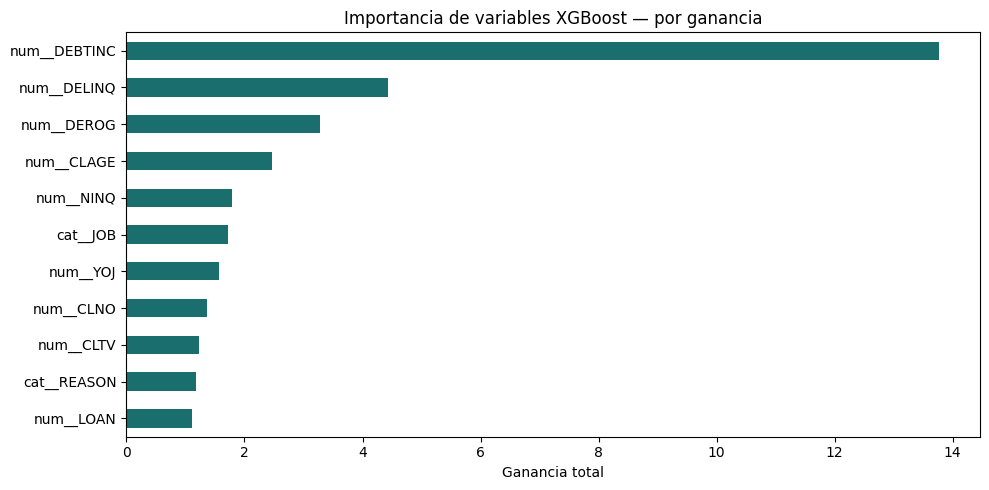

In [27]:
import seaborn as sns

#  Gráfico 3 — Importancia de variables por ganancia 
plt.figure(figsize=(10, 5))
importancias_xgb_gain_nombradas.sort_values().plot(kind="barh", color="#1B6E6E")
plt.title("Importancia de variables XGBoost — por ganancia")
plt.xlabel("Ganancia total")
plt.tight_layout()
plt.show()

c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
c:\Users\karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


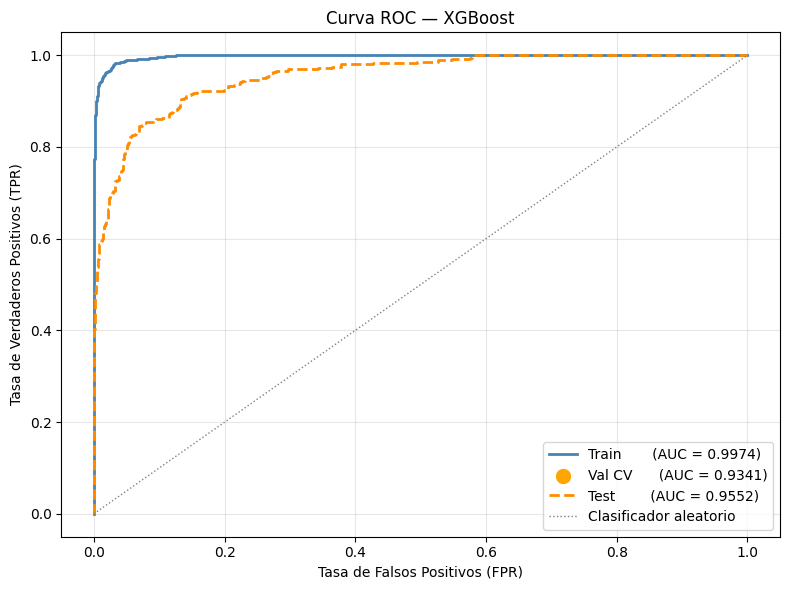

AUC-ROC train    : 0.9974
AUC-ROC val CV   : 0.9341
AUC-ROC test     : 0.9552


In [28]:
from sklearn.metrics import roc_curve, roc_auc_score

# ── Probabilidades predichas

# Train — el modelo predice sobre los mismos datos con los que se entrenó
y_pred_proba_train = best_model_xgb_mono.predict_proba(X_train)[:, 1]

# Test — datos nunca vistos durante el entrenamiento
y_pred_proba_test  = best_model_xgb_mono.predict_proba(X_test)[:, 1]

# ── Curvas ROC
fpr_train, tpr_train, _ = roc_curve(y_train, y_pred_proba_train)
fpr_test,  tpr_test,  _ = roc_curve(y_test,  y_pred_proba_test)

auc_train_final = roc_auc_score(y_train, y_pred_proba_train)
auc_val_final   = gs_xgb_3.best_score_
auc_test_final  = roc_auc_score(y_test,  y_pred_proba_test)

# ── Gráfico
plt.figure(figsize=(8, 6))

# Curva train
plt.plot(fpr_train, tpr_train,
    label=f"Train       (AUC = {auc_train_final:.4f})",
    color="steelblue", linewidth=2)

# Curva validación CV — no tiene curva ROC directa, se representa como punto
plt.scatter([], [],
            label=f"Val CV      (AUC = {auc_val_final:.4f})",
            color="orange", s=100)

# Curva test
plt.plot(fpr_test, tpr_test,
    label=f"Test        (AUC = {auc_test_final:.4f})",
    color="darkorange", linewidth=2, linestyle="--")

# Línea de referencia — clasificador aleatorio
plt.plot([0, 1], [0, 1],
    color="gray", linewidth=1, linestyle=":", label="Clasificador aleatorio")

plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curva ROC — XGBoost")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC-ROC train    : {auc_train_final:.4f}")
print(f"AUC-ROC val CV   : {auc_val_final:.4f}")
print(f"AUC-ROC test     : {auc_test_final:.4f}")

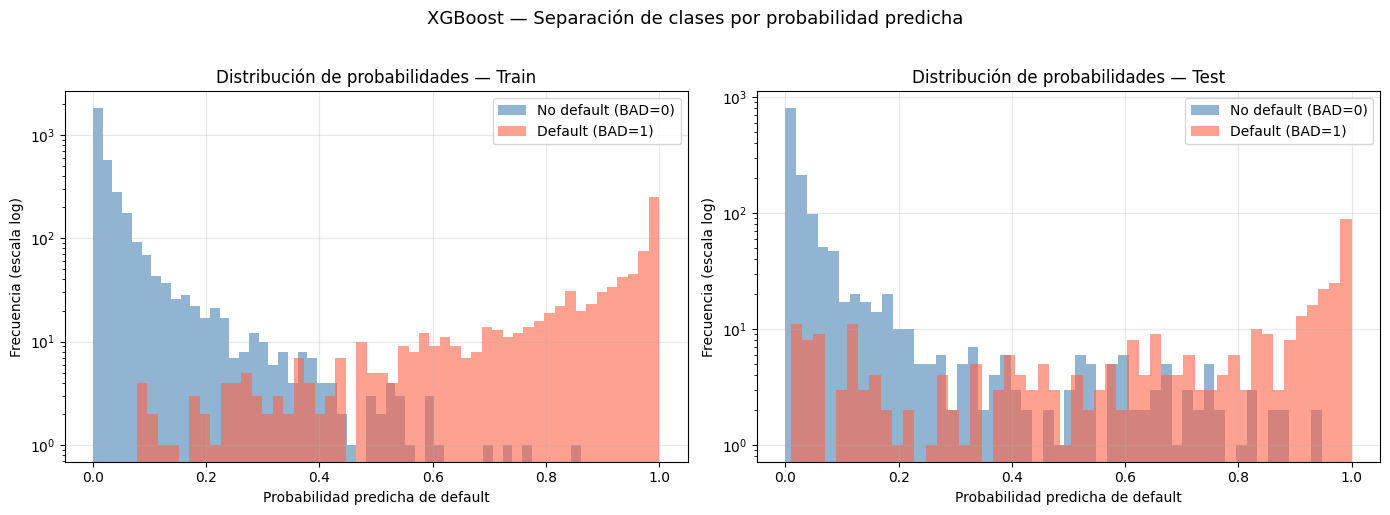

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train 
axes[0].hist(
    y_pred_proba_train[y_train == 0],
    bins=50, alpha=0.6, color="steelblue", label="No default (BAD=0)"
)
axes[0].hist(
    y_pred_proba_train[y_train == 1],
    bins=50, alpha=0.6, color="tomato", label="Default (BAD=1)"
)
axes[0].set_yscale("log")                          # ← escala logarítmica
axes[0].set_title("Distribución de probabilidades — Train")
axes[0].set_xlabel("Probabilidad predicha de default")
axes[0].set_ylabel("Frecuencia (escala log)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Test
axes[1].hist(
    y_pred_proba_test[y_test == 0],
    bins=50, alpha=0.6, color="steelblue", label="No default (BAD=0)"
)
axes[1].hist(
    y_pred_proba_test[y_test == 1],
    bins=50, alpha=0.6, color="tomato", label="Default (BAD=1)"
)
axes[1].set_yscale("log")                          # ← escala logarítmica
axes[1].set_title("Distribución de probabilidades — Test")
axes[1].set_xlabel("Probabilidad predicha de default")
axes[1].set_ylabel("Frecuencia (escala log)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("XGBoost — Separación de clases por probabilidad predicha",
    fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Interpretación

Train (izquierda). Los no defaults se concentran cerca de 0 y los defaults cerca de 1, con una separación marcada pero no perfecta: la monotonía deja una cola de no defaults hacia 0,2 y una distribución de defaults más dispersa en la zona central, coherente con un AUC train de 0,9974.

Test (derecha). El solapamiento crece en la franja central (0,2 a 0,8), donde ambas clases se mezclan. Es la contrapartida esperable fuera de muestra y explica el AUC test de 0,9552, en línea con el benchmark monótono de LightGBM (0,9547).

Conclusiones

1. Los dos modelos de boosting alcanzan una discriminación equivalente
Con el mismo tratamiento de NaN y de monotonía, XGBoost (AUC test 0,9552) y LightGBM (0,9547) quedan prácticamente igualados, sin que ninguno domine. Ambos se mantienen como benchmark frente a la Regresión Logística con WoE, cuya comparación detallada se desarrolla en el Capítulo 6.

2. El ajuste perfecto en train es estructural, no metodológico
El modelo sin restringir alcanza un AUC train de 1,0000, y la monotonía apenas lo rebaja (0,9974). Tres evidencias descartan sobreajuste: la diferencia val/test es negativa (el test supera a la validación cruzada), la diferencia train/val se sitúa en el límite del umbral aceptable de 0,05, y la distribución de probabilidades en test muestra un solapamiento de clases propio de una generalización real.

3. Las variables más predictivas coinciden entre modelos
Por ganancia, DEBTINC es la más informativa con diferencia, seguida de DELINQ y DEROG. El ranking es similar al de LightGBM, y esa coincidencia entre dos algoritmos independientes respalda el EDA: las variables con mayor IV en el análisis previo son las que dominan el poder predictivo.

4. Ambos superan ampliamente el baseline regulatorio
En el marco IRB de Basilea III, un AUC-ROC por encima de 0,80 indica buena capacidad discriminante. Tanto XGBoost (0,9552) como LightGBM (0,9547) lo rebasan con holgura.

#### Persistencia de artefactos

In [30]:
# Persistencia de artefactos — consumidos por el notebook 05 de comparación

import joblib
from pathlib import Path

models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)

# Solo guardamos el Pipeline de XGBoost
# X_test/y_test ya quedaron persistidos desde el notebook 03 (single source of truth)
joblib.dump(best_model_xgb_mono, models_dir / "xgb_pipeline.pkl")

['..\\models\\xgb_pipeline.pkl']

In [31]:
cltv_transformer = best_model_xgb_mono.named_steps["prep_xgb"].transformers_[0][1].named_steps["cltv"]
print("Clase:  ", type(cltv_transformer).__name__)
print("Módulo: ", type(cltv_transformer).__module__)

Clase:   CLTVTransformer
Módulo:  src.transformers
